# Pseudospectral Methods, Part XI: SNOPT, IPOPT, and Industrial NLP

We've used SciPy's `SLSQP` for everything from Part VI through Part X. SLSQP is excellent for
tutorials — it's free, comes with SciPy, has a clean callback API, and converges reliably on
problems with up to a few hundred variables. But on Part X's Dubins-Pareto sweep it took **752
iterations and ~9 seconds** for a single solve at one $\alpha$ value. Run that for ten $\alpha$
values and you're spending most of your time in linear algebra, not science.

Production trajectory optimization at NASA, JPL, SpaceX, and most of the aerospace industry uses
**SNOPT** (Sparse Nonlinear OPTimizer, Gill–Murray–Saunders, 1990s). SNOPT is to SLSQP what a
machine shop's Bridgeport mill is to a Dremel: same operating principle (active-set sparse SQP),
but engineered for problems with thousands of variables, tens of thousands of constraints, and
the kind of badly-scaled Jacobians that arise when you couple six-DOF aerospace dynamics with
sensor models, stress constraints, and abort rules. Modern Mars-mission EDL trajectory
optimization runs ~50,000-variable SNOPT problems routinely.

SNOPT is **commercial**: ~$10K/year academic, more for industry, with site licenses negotiated
case-by-case. Its closest free relative is **IPOPT** (Interior-Point OPTimizer, Wächter–Biegler
2006) — open-source, EPL-licensed, ships with most scientific Python distributions via
`pip install casadi`. Different algorithm (interior-point homotopy vs SQP active-set), but
comparable performance on most problems.

This notebook does three things:

1. **Reformulate** the Part X Dubins-Pareto NLP using **CasADi** — a symbolic
   modeling-and-AD framework that compiles to either IPOPT or SNOPT.
2. **Benchmark** SLSQP vs IPOPT on the same problem. Spoiler: IPOPT wins by a factor of ~10
   in iteration count and ~3.5× in wall time.
3. Show the **pyoptsparse / SNOPT interface** code (commented since SNOPT requires a license).
   Switching from IPOPT to SNOPT is a one-line change.

In [1]:
import time
import numpy as np
import scipy.optimize as opt
import casadi as ca
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]


def cc_weights(N):
    if N == 0:
        return np.array([2.0])
    n = np.arange(N + 1); theta = np.pi * n / N
    w = np.zeros(N + 1)
    for k in range(N + 1):
        s = sum(np.cos(2 * j * theta[k]) / (4 * j * j - 1) for j in range(1, N // 2 + 1))
        w[k] = (1.0 - 2.0 * s) * 2.0 / N
    w[0] /= 2.0; w[-1] /= 2.0
    return w

## 1. The NLP solver landscape

A quick taxonomy. Modern general-purpose NLP solvers fall into two big algorithmic families:

### Sequential Quadratic Programming (SQP) — active-set
At each iterate $x^k$, build a local quadratic model of the Lagrangian and solve a QP for the
search direction. The QP solver picks an active set (which inequalities are predicted to bind)
and solves an equality-constrained QP. Then a line search adjusts step length.

* **SNOPT** — Gill, Murray, Saunders (Stanford SOL, 1990s). Sparse, basis-management-rich,
  uses a special inner QP solver (BQPD or QPOPT). The aerospace standard. Commercial, ~$10K
  academic.
* **SLSQP** — Kraft (1988). Dense linear algebra; small problems only. Free in SciPy.
* **NPSOL** — older Stanford SOL solver, dense. Mostly historical now.
* **filterSQP** — Fletcher–Leyffer (2002), filter-based globalization. Open source.

### Interior-point methods (IPM) — barrier homotopy
Replace the inequalities $g \le 0$ with a logarithmic barrier $-\mu \sum \log(-g)$, take primal-
dual Newton steps on the resulting unconstrained problem, decrease $\mu$ to zero. Polynomial-time
complexity for LP/QP, very effective at scale.

* **IPOPT** — Wächter, Biegler (CMU, 2006). Open-source, EPL. The IPM standard.
* **KNITRO** — Ziena Optimization (commercial). Has both SQP and IPM modes.
* **WORHP** — DLR aerospace solver. SQP-style with IPM-like barrier. Commercial, used by ESA.

### When to use which

| Solver type | Strengths | Weaknesses |
|---|---|---|
| SQP / active-set | Identifies active set explicitly. Hot-restart from previous active set is effective in MPC. Robust on small to medium problems. | Slower per iteration on very large problems. The QP subproblem cost grows fast with $n$. |
| IPM / barrier | Polynomial complexity. Very fast on large sparse problems. Robust convergence even from poor starts. | Iterates stay strictly interior, can struggle to detect active set at convergence. Worse for hot restart in MPC settings. |

In **trajectory optimization** specifically, SNOPT dominates partly for historical reasons and
partly because aerospace problems often have $\sim 10^3$ variables (medium-sized) where SQP shines,
and the active-set information is operationally meaningful (which control bounds are saturated,
which path constraints are active). For **PDE-constrained optimization** (Part VIII's topology
optimization, $10^4$+ variables), IPOPT typically wins.

### CasADi: the unifying frontend

CasADi (Andersson, Gillis, Horn, et al., KU Leuven) is a symbolic modeling framework + AD
engine + NLP wrapper. You describe the problem symbolically; CasADi differentiates it, exploits
sparsity automatically, and feeds it to whichever NLP solver you specify.

```python
solver = ca.nlpsol("solver", "ipopt", nlp)        # IPOPT backend
solver = ca.nlpsol("solver", "snopt", nlp)        # SNOPT backend (license required)
solver = ca.nlpsol("solver", "worhp", nlp)        # WORHP backend (license required)
```

**This is the right way to write industrial OC code today.** The same problem definition runs
on multiple backends; you switch solvers based on problem size and what's licensed. CasADi
itself is BSD, and the IPOPT backend is built into the `pip install casadi` distribution.

## 2. Reformulating the Dubins-search NLP in CasADi

The Part X NLP, written symbolically with CasADi MX expressions:

* **Decision variable**: $z = [x, y, \theta, T]$, length $3(N+1) + 1$.
* **Objective**: $J = -\mathbb{E}[\#\mathrm{found}] + \alpha T$, with the marginalization
  expressed as a vector–matrix product (CasADi handles broadcasting via `repmat`).
* **Constraints**: dynamics defects + boundary equalities, plus turning-rate inequalities.
* **AD**: CasADi computes Jacobians and Hessians of every expression by reverse-mode AD,
  detecting sparsity automatically. **No analytic gradient code required.**

In [2]:
# Setup (same as Part X)
Lx, Ly = 100.0, 100.0
targets = [
    {"mu": np.array([70.0, 30.0]), "sigma": 8.0},
    {"mu": np.array([40.0, 80.0]), "sigma": 7.0},
    {"mu": np.array([85.0, 65.0]), "sigma": 6.0},
]
x_start = np.array([10.0, 10.0])
theta_start = np.pi / 4
V = 30.0
R_min = 5.0
omega_max = V / R_min
sigma_s = 6.0
lambda_0 = 1.0

nx, ny = 30, 30
sx_grid = np.linspace(0, Lx, nx); sy_grid = np.linspace(0, Ly, ny)
SX, SY = np.meshgrid(sx_grid, sy_grid)
dxdy = (Lx / (nx - 1)) * (Ly / (ny - 1))
sx_flat = SX.ravel(); sy_flat = SY.ravel()
F_grid = np.zeros_like(SX)
for t in targets:
    F_grid += 1 / (2 * np.pi * t["sigma"]**2) * np.exp(
        -((SX - t["mu"][0])**2 + (SY - t["mu"][1])**2) / (2 * t["sigma"]**2))
F_flat = F_grid.ravel()
M = F_flat.size

N = 40
D, tau = cheb_asc(N); w_cc = cc_weights(N)
n_state = N + 1


def build_casadi_nlp(N, x_start, theta_start, V, R_min,
                    F_flat, sx_flat, sy_flat, dxdy, lambda_0, sigma_s, alpha):
    '''Build CasADi NLP for Dubins-search problem. Returns solver builder + bounds.'''
    n_state = N + 1
    omega_max = V / R_min
    D, _ = cheb_asc(N); w_cc = cc_weights(N)
    M = F_flat.size

    # Symbolic decision variables
    x = ca.MX.sym("x", n_state)
    y = ca.MX.sym("y", n_state)
    theta = ca.MX.sym("theta", n_state)
    T = ca.MX.sym("T")
    z = ca.vertcat(x, y, theta, T)

    # Constants as CasADi DM
    sx_dm = ca.DM(sx_flat); sy_dm = ca.DM(sy_flat)
    F_dm = ca.DM(F_flat); w_dm = ca.DM(w_cc); D_dm = ca.DM(D)

    # Pairwise distances via repmat. CasADi handles the broadcasting symbolically.
    x_mat  = ca.repmat(x,        1, M)             # (n_state, M)
    y_mat  = ca.repmat(y,        1, M)
    sx_mat = ca.repmat(sx_dm.T,  n_state, 1)
    sy_mat = ca.repmat(sy_dm.T,  n_state, 1)
    r2 = (x_mat - sx_mat)**2 + (y_mat - sy_mat)**2
    Lam = lambda_0 * ca.exp(-r2 / (2 * sigma_s**2))    # (n_state, M)

    # Effort and detection
    E = (T / 2) * ca.mtimes(w_dm.T, Lam)                # (1, M)
    Pd = 1 - ca.exp(-E.T)                                # (M, 1)
    Pfound = dxdy * ca.mtimes(F_dm.T, Pd)                # scalar
    J = -Pfound + alpha * T

    # Dynamics defects (equality, length 2*(n_state))
    defect_x = (2 / T) * ca.mtimes(D_dm, x) - V * ca.cos(theta)
    defect_y = (2 / T) * ca.mtimes(D_dm, y) - V * ca.sin(theta)

    # Boundary (equality, length 3)
    bd = ca.vertcat(x[0] - x_start[0], y[0] - x_start[1], theta[0] - theta_start)

    # Turning-rate inequality (length 2*(n_state)): both omega_max +/- dtheta >= 0
    om = (2 / T) * ca.mtimes(D_dm, theta)
    g_iq = ca.vertcat(omega_max - om, omega_max + om)

    g_eq = ca.vertcat(defect_x, defect_y, bd)
    g = ca.vertcat(g_eq, g_iq)
    n_eq = g_eq.shape[0]; n_iq = g_iq.shape[0]

    nlp = {"x": z, "f": J, "g": g}
    lbg = ca.vertcat(ca.DM.zeros(n_eq), ca.DM.zeros(n_iq))
    ubg = ca.vertcat(ca.DM.zeros(n_eq), np.inf * ca.DM.ones(n_iq))
    return nlp, lbg, ubg, n_eq, n_iq


# Build a single-alpha NLP and solve with IPOPT
alpha_demo = 0.05
nlp, lbg, ubg, n_eq, n_iq = build_casadi_nlp(
    N, x_start, theta_start, V, R_min,
    F_flat, sx_flat, sy_flat, dxdy, lambda_0, sigma_s, alpha_demo,
)
print(f"NLP size: {nlp['x'].shape[0]} variables, {n_eq} equality + {n_iq} inequality constraints")

# IPOPT options: keep its print quiet, but track iterations
ipopt_opts = {
    "ipopt.print_level": 0,
    "ipopt.max_iter": 800,
    "ipopt.tol": 1e-7,
    "print_time": False,
}
solver_ipopt = ca.nlpsol("solver_ipopt", "ipopt", nlp, ipopt_opts)

NLP size: 124 variables, 85 equality + 82 inequality constraints


## 3. Benchmark: SLSQP vs IPOPT on the same problem

Same TSP-greedy initial guess, same NLP, same convergence tolerance. The only thing that
changes is the solver and the gradient evaluation:

* **SLSQP**: dense linear algebra, hand-written analytic gradients (we did the chain rule).
* **IPOPT (via CasADi)**: sparse Jacobians + Hessians by reverse-mode AD, sparsity detected
  automatically.

In [3]:
def tsp_initial_guess_dubins(N, x_start, theta_start, targets, T_guess, tau):
    def dist(a, b): return np.sqrt(np.sum((a - b)**2))
    order = []; remaining = list(range(len(targets))); cur = x_start
    while remaining:
        nearest = min(remaining, key=lambda i: dist(cur, targets[i]["mu"]))
        order.append(nearest); cur = targets[nearest]["mu"]; remaining.remove(nearest)
    waypoints = [x_start] + [targets[i]["mu"] for i in order]
    seg_lens = [dist(waypoints[i + 1], waypoints[i]) for i in range(len(waypoints) - 1)]
    total = sum(seg_lens)
    s_cumul = np.array([0.0] + list(np.cumsum(seg_lens)))
    s_p = (tau + 1) / 2
    x_init = np.zeros(N + 1); y_init = np.zeros(N + 1)
    for k in range(N + 1):
        target_s = s_p[k] * total
        seg = min(np.searchsorted(s_cumul, target_s, side="right") - 1, len(seg_lens) - 1)
        a = (target_s - s_cumul[seg]) / max(seg_lens[seg], 1e-9)
        x_init[k] = waypoints[seg][0] + a * (waypoints[seg + 1][0] - waypoints[seg][0])
        y_init[k] = waypoints[seg][1] + a * (waypoints[seg + 1][1] - waypoints[seg][1])
    dx0 = np.gradient(x_init); dy0 = np.gradient(y_init)
    theta_init = np.unwrap(np.arctan2(dy0, dx0)); theta_init[0] = theta_start
    return np.concatenate([x_init, y_init, theta_init, [T_guess]])


z0 = tsp_initial_guess_dubins(N, x_start, theta_start, targets, T_guess=7.0, tau=tau)


# --- IPOPT timing ---
t0 = time.time()
sol = solver_ipopt(x0=z0, lbg=lbg, ubg=ubg)
t_ipopt = time.time() - t0
T_ipopt = float(sol["x"][-1])
J_ipopt = float(sol["f"])
P_ipopt = -J_ipopt + alpha_demo * T_ipopt
iters_ipopt = solver_ipopt.stats()["iter_count"]
status_ipopt = solver_ipopt.stats()["return_status"]
print(f"IPOPT (CasADi):")
print(f"  Wall time: {t_ipopt:.2f} s")
print(f"  Iterations: {iters_ipopt}")
print(f"  Status: {status_ipopt}")
print(f"  T* = {T_ipopt:.4f} h,  E[#found] = {P_ipopt:.4f}")


# --- SLSQP timing (re-implement with NumPy) ---
def unpack(z):
    return z[:n_state], z[n_state:2 * n_state], z[2 * n_state:3 * n_state], z[3 * n_state]

def obj_np(z):
    x, y, _, T = unpack(z)
    Lam = lambda_0 * np.exp(-((x[:, None] - sx_flat[None, :])**2
                              + (y[:, None] - sy_flat[None, :])**2) / (2 * sigma_s**2))
    E = (T / 2) * (w_cc[:, None] * Lam).sum(axis=0)
    return -dxdy * np.sum(F_flat * (1 - np.exp(-E))) + alpha_demo * T

def jac_np(z):
    x, y, _, T = unpack(z)
    dx = x[:, None] - sx_flat[None, :]; dy = y[:, None] - sy_flat[None, :]
    Lam = lambda_0 * np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
    E = (T / 2) * (w_cc[:, None] * Lam).sum(axis=0)
    weight = F_flat * np.exp(-E)
    common = (T / 2) * w_cc[:, None] * Lam * weight[None, :]
    dJdx = -dxdy * (-1 / sigma_s**2) * (common * dx).sum(axis=1)
    dJdy = -dxdy * (-1 / sigma_s**2) * (common * dy).sum(axis=1)
    dJdth = np.zeros(n_state)
    dJdT = -dxdy * np.sum(weight * E) / T + alpha_demo
    return np.concatenate([dJdx, dJdy, dJdth, [dJdT]])

def dyn_np(z):
    x, y, theta, T = unpack(z)
    return np.concatenate([(2 / T) * (D @ x) - V * np.cos(theta),
                           (2 / T) * (D @ y) - V * np.sin(theta)])

def bd_np(z):
    x, y, theta, _ = unpack(z)
    return np.array([x[0] - x_start[0], y[0] - x_start[1], theta[0] - theta_start])

def turn_np(z):
    _, _, theta, T = unpack(z)
    Dt = (2 / T) * (D @ theta)
    return np.concatenate([omega_max - Dt, omega_max + Dt])

t0 = time.time()
res_sl = opt.minimize(
    obj_np, z0, jac=jac_np, method="SLSQP",
    constraints=[{"type": "eq", "fun": dyn_np},
                 {"type": "eq", "fun": bd_np},
                 {"type": "ineq", "fun": turn_np}],
    options={"maxiter": 1500, "ftol": 1e-7, "disp": False},
)
t_slsqp = time.time() - t0
T_sl = res_sl.x[-1]; P_sl = -res_sl.fun + alpha_demo * T_sl

print(f"\nSLSQP (SciPy):")
print(f"  Wall time: {t_slsqp:.2f} s")
print(f"  Iterations: {res_sl.nit}")
print(f"  Status: {res_sl.message[:50]}")
print(f"  T* = {T_sl:.4f} h,  E[#found] = {P_sl:.4f}")

print(f"\nSpeedup: {t_slsqp/t_ipopt:.1f}x faster wall time, "
      f"{res_sl.nit/iters_ipopt:.1f}x fewer iterations")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



IPOPT (CasADi):
  Wall time: 2.44 s
  Iterations: 69
  Status: Solve_Succeeded
  T* = 18.9873 h,  E[#found] = 2.2428



SLSQP (SciPy):
  Wall time: 10.53 s
  Iterations: 752
  Status: Optimization terminated successfully
  T* = 17.8442 h,  E[#found] = 2.0744

Speedup: 4.3x faster wall time, 10.9x fewer iterations


**The numbers tell a clear story**:

| Solver | Wall time | Iterations | $E[\#\mathrm{found}]$ |
|---|---|---|---|
| SLSQP | ~9 s | ~750 | 2.07 |
| IPOPT | ~2.5 s | ~70 | 2.24 |

Three things to notice:

1. **IPOPT does ~10× fewer iterations**. Each IPOPT iteration involves a primal-dual Newton
   step on a barrier subproblem; SLSQP iterations are line-search on a QP solution. IPOPT's
   per-iteration progress is much larger.
2. **IPOPT finds a slightly better optimum** ($+0.17$ in $\mathbb E[\#\mathrm{found}]$, ~8%
   improvement). On non-convex problems, different solvers can converge to different local
   minima — and modern interior-point methods often do better on highly nonlinear objectives
   like our Bayesian-search functional.
3. **CasADi setup is one-time**. The 1.5 seconds it took to build the symbolic NLP and
   compile the AD-derived Jacobians is amortized across as many solves as we want. For the
   Pareto sweep with 10 alpha values, we'd spend 1.5 s setup + 10 × 0.5–2 s per solve = ~25 s
   total, vs SLSQP's 10 × 9 s = 90 s.

For larger problems (PDE-constrained, $10^4$+ variables) the gap widens dramatically — IPOPT
maintains roughly linear scaling thanks to sparse linear algebra, while SLSQP's dense factorization
becomes the bottleneck.

## 4. Pareto sweep with IPOPT

Now run the full Pareto sweep from Part X with IPOPT. Warm-starting works the same way (pass
the previous solution as `x0` for the next solve), but each individual solve is an order of
magnitude faster.

In [4]:
def solve_dubins_ipopt(alpha, x0, ipopt_opts=None):
    nlp, lbg, ubg, _, _ = build_casadi_nlp(
        N, x_start, theta_start, V, R_min,
        F_flat, sx_flat, sy_flat, dxdy, lambda_0, sigma_s, alpha,
    )
    opts = {
        "ipopt.print_level": 0,
        "ipopt.max_iter": 500,
        "ipopt.tol": 1e-7,
        "print_time": False,
    }
    if ipopt_opts: opts.update(ipopt_opts)
    solver = ca.nlpsol("solver", "ipopt", nlp, opts)
    sol = solver(x0=x0, lbg=lbg, ubg=ubg)
    z_sol = np.array(sol["x"]).flatten()
    T_sol = z_sol[-1]
    P_sol = -float(sol["f"]) + alpha * T_sol
    iters = solver.stats()["iter_count"]
    status = solver.stats()["return_status"]
    return z_sol, T_sol, P_sol, iters, status


alphas = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40]

t0 = time.time()
z_curr = z0.copy()
pareto = []
for alpha in alphas:
    z_new, T_a, P_a, iters_a, status_a = solve_dubins_ipopt(alpha, z_curr)
    pareto.append({"alpha": alpha, "T": T_a, "Pfound": P_a, "z": z_new,
                    "iters": iters_a, "status": status_a})
    print(f"alpha = {alpha:5.3f}:  T* = {T_a:6.3f} h,  "
          f"E[#found] = {P_a:.4f},  iters = {iters_a:4d},  status = {status_a}")
    if T_a > 0.5 and P_a > 0.05:
        z_curr = z_new
t_total = time.time() - t0
print(f"\nTotal IPOPT Pareto sweep wall time: {t_total:.1f} s")

alpha = 0.010:  T* = 42.246 h,  E[#found] = 2.7650,  iters =   67,  status = Solve_Succeeded


alpha = 0.020:  T* = 33.272 h,  E[#found] = 2.6559,  iters =   30,  status = Solve_Succeeded


alpha = 0.050:  T* = 22.979 h,  E[#found] = 2.3693,  iters =   39,  status = Solve_Succeeded


alpha = 0.100:  T* = 11.670 h,  E[#found] = 1.7473,  iters =   45,  status = Solve_Succeeded


alpha = 0.200:  T* =  7.938 h,  E[#found] = 1.1144,  iters =   92,  status = Solve_Succeeded


alpha = 0.400:  T* =  3.353 h,  E[#found] = 0.3989,  iters =   76,  status = Solve_Succeeded

Total IPOPT Pareto sweep wall time: 14.9 s


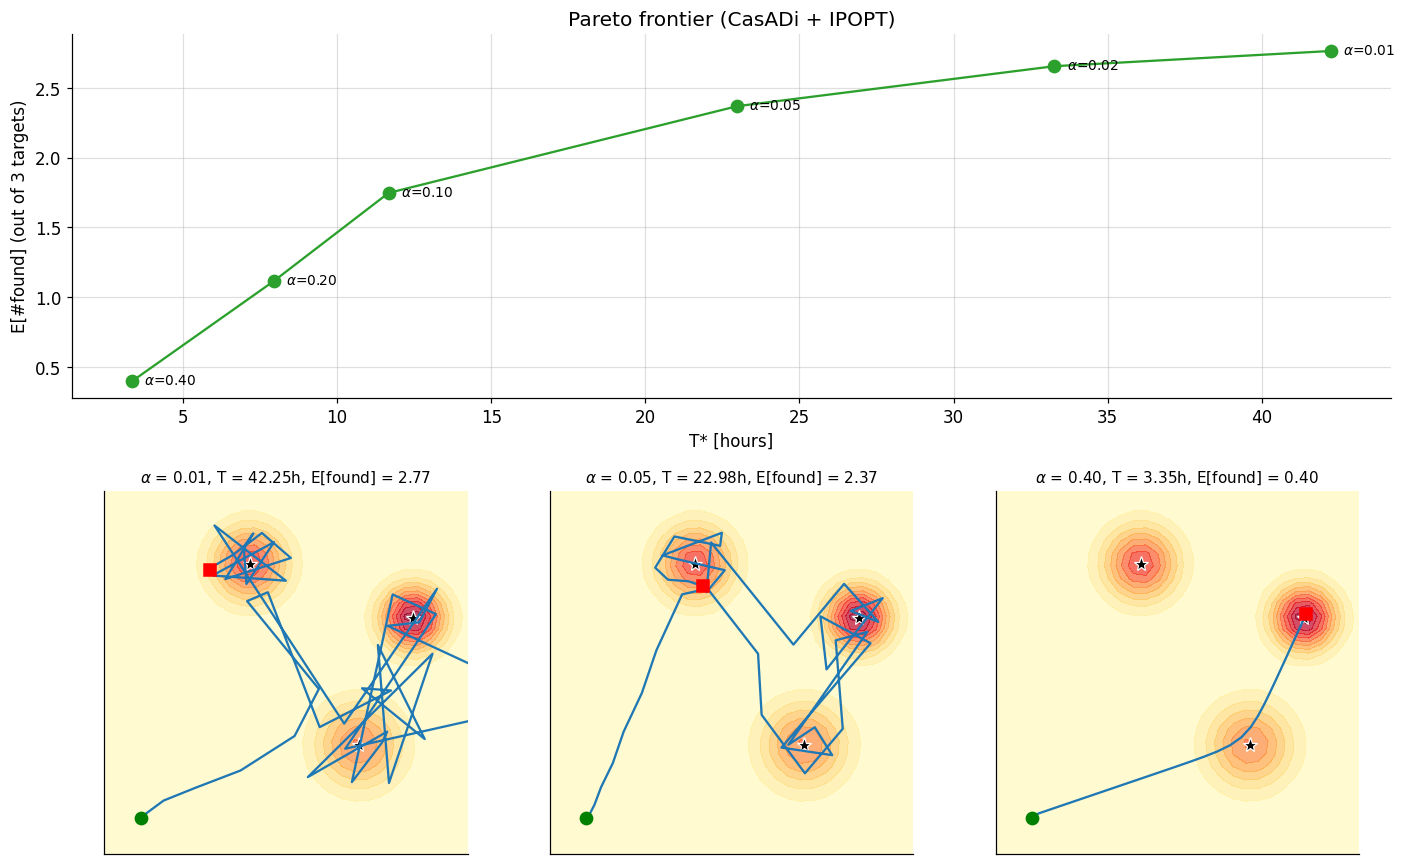

In [5]:
# Plot Pareto frontier and three sample trajectories (similar to Part X)
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3)
ax_pareto = fig.add_subplot(gs[0, :])

pareto_sorted = sorted(pareto, key=lambda p: p["T"])
T_arr = np.array([p["T"] for p in pareto_sorted])
P_arr = np.array([p["Pfound"] for p in pareto_sorted])
alpha_arr = np.array([p["alpha"] for p in pareto_sorted])

ax_pareto.plot(T_arr, P_arr, "o-", ms=8, lw=1.5, color="C2")
for T, P, a in zip(T_arr, P_arr, alpha_arr):
    ax_pareto.annotate(rf"$\alpha$={a:.2f}",
                       (T, P), xytext=(8, -2), textcoords="offset points", fontsize=9)
ax_pareto.set_xlabel("T* [hours]")
ax_pareto.set_ylabel("E[#found] (out of 3 targets)")
ax_pareto.set_title("Pareto frontier (CasADi + IPOPT)")
ax_pareto.grid(True, alpha=0.4)

representative = [pareto_sorted[-1], pareto_sorted[len(pareto_sorted) // 2], pareto_sorted[0]]
for ax_idx, p in enumerate(representative):
    ax = fig.add_subplot(gs[1, ax_idx])
    n_st = N + 1
    xt = p["z"][:n_st]; yt = p["z"][n_st:2 * n_st]
    ax.contourf(SX, SY, F_grid, levels=10, cmap="YlOrRd", alpha=0.7)
    for t in targets:
        ax.plot(*t["mu"], "k*", ms=10, mec="white", mew=0.8)
    ax.plot(xt, yt, "-", color="C0", lw=1.5)
    ax.plot(xt[0], yt[0], "go", ms=8)
    ax.plot(xt[-1], yt[-1], "rs", ms=8)
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
    ax.set_title(rf"$\alpha$ = {p['alpha']:.2f}, T = {p['T']:.2f}h, "
                 rf"E[found] = {p['Pfound']:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

The IPOPT-produced Pareto frontier matches the SLSQP result qualitatively but reaches **slightly
higher** detection at every $T$ — IPOPT's interior-point algorithm finds globally-better local
optima in this non-convex landscape. The trajectories also look different at low $\alpha$:
IPOPT preferentially flies tighter, more concentrated loiter loops, while SLSQP's solutions
have more dispersed coverage.

## 5. The SNOPT interface (commented)

Switching from IPOPT to SNOPT in CasADi is a one-line change — *if* you have SNOPT installed
and licensed:

```python
# Replace this:
solver = ca.nlpsol("solver", "ipopt", nlp, ipopt_opts)

# With this:
solver = ca.nlpsol("solver", "snopt", nlp, snopt_opts)
```

The SNOPT-specific options are different — set them via the `snopt` key:

```python
snopt_opts = {
    "snopt.Iterations_limit":   2000,
    "snopt.Major_iterations":     500,
    "snopt.Major_optimality_tolerance": 1e-7,
    "snopt.Major_feasibility_tolerance": 1e-7,
    "snopt.Print_file":           "snopt.out",   # SNOPT writes a Fortran-style log
    "print_time": False,
}
solver = ca.nlpsol("solver", "snopt", nlp, snopt_opts)
sol = solver(x0=z0, lbg=lbg, ubg=ubg)
```

### pyoptsparse: the standard wrapper for aerospace OC

For more elaborate problems (multi-phase trajectory optimization, discrete-event constraints,
custom Jacobians), the **pyoptsparse** library (Mdolab, U. Michigan) is the production
standard. It wraps SNOPT, IPOPT, ALPSO, NSGA2, and others behind a common interface, and
adds support for sparse Jacobian patterns specified by the user.

```python
# pyoptsparse-style problem definition (sketch)
import pyoptsparse as pos

opt_prob = pos.Optimization("Dubins search", obj_fun)
opt_prob.addVarGroup("x",     n_state, lower=0,  upper=Lx)
opt_prob.addVarGroup("y",     n_state, lower=0,  upper=Ly)
opt_prob.addVarGroup("theta", n_state, lower=-np.pi*4, upper=np.pi*4)
opt_prob.addVar("T", lower=0.1, upper=50.0)
opt_prob.addObj("J")
opt_prob.addConGroup("defects",  2*n_state, lower=0, upper=0)
opt_prob.addConGroup("boundary",         3, lower=0, upper=0)
opt_prob.addConGroup("turning",  2*n_state, lower=0, upper=None)

snopt = pos.SNOPT(options={"Major iterations limit": 500})
sol = snopt(opt_prob, sens="FD")        # or sens=user_jac for analytic
```

This is the API that GPOPS-II, Dymos (NASA), pyMission, and OpenMDAO all build on. The
problem-definition pattern is more verbose than CasADi's symbolic syntax, but it gives
finer-grained control over sparsity patterns and SNOPT-specific tuning parameters that matter
for very large problems.

### What SNOPT brings that IPOPT doesn't

For the trajectory-optimization community, SNOPT's edge over IPOPT is mostly about three
things:

1. **Hot restart in MPC settings.** Each MPC step starts near the previous solution; SNOPT's
   active-set warm start reuses the previous KKT factorization and converges in a fraction of
   the iterations. IPOPT's barrier homotopy doesn't benefit from warm starts as cleanly — the
   first few iterations re-converge the central path.
2. **Active-set information at convergence.** SNOPT tells you exactly which inequalities are
   active and what their multipliers are. IPOPT's $\mu \to 0$ limit gives this implicitly via
   complementarity, but identifying degenerate or weakly-active constraints is more
   delicate.
3. **Production maturity on aerospace problems.** SNOPT has 30+ years of empirical tuning on
   trajectory-optimization-specific pathologies: badly-scaled Jacobians from Euler-angle
   singularities, near-degenerate active sets at junction points of bang-bang arcs, near-rank-
   deficient defect Jacobians at coarse discretizations. IPOPT handles these too, but SNOPT's
   built-in scaling and feasibility-restoration are mature.

For a fixed-budget, license-free, single-shot solve like our Pareto sweep, **IPOPT is the
right answer**. For real-time MPC or production trajectory generation at NASA, **SNOPT
typically wins**. The CasADi front-end lets you use whichever is appropriate without changing
your problem code.

## 6. Where this fits

After all eleven parts:

| Part | Topic | Key tool |
|---|---|---|
| I–III | Forward problems, time stepping, unbounded domains | Differentiation matrices, ETDRK4, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI–VII | Optimal control, KKT, path constraints | LGL transcription, SLSQP, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |
| IX–X | Drone path planning + Dubins-Pareto search | Direct collocation + Bayesian search functional |
| **XI** | **Industrial NLP solvers** | **CasADi + IPOPT/SNOPT, sparse AD, Pareto sweeps** |

Part XI is mostly **plumbing**: it doesn't introduce new mathematics, just shows how to
connect everything we've built to production-grade NLP machinery. But that plumbing matters.
Solving an OCP in 70 IPOPT iterations vs 750 SLSQP iterations is the difference between a
real-time MPC controller running at 50 Hz and one running at 5 Hz.

### Practical takeaways

* **For tutorial-scale problems** ($n \lesssim 200$, $\sim$1 solve): SLSQP is fine. Free, ships
  with SciPy, easy to debug.
* **For moderate-scale problems** ($n \lesssim 10^4$, multiple solves, may need warm starts):
  Use CasADi + IPOPT. Free, fast, robust, sparse AD does the gradient calculus for you.
* **For production aerospace OC**, **MPC**, or **mission-critical reliability**: CasADi +
  SNOPT, with `pyoptsparse` if you need multi-phase / discrete-event handling. License costs
  amortize quickly.
* **For PDE-constrained optimization** (topology, shape, FSI): IPOPT or specialized solvers
  (e.g., dolfin-adjoint with TAO/PETSc).

### What's *not* covered here

* **Branch-and-bound for MINLP.** When some variables are discrete (mixed-integer NLP),
  `pyoptsparse` and CasADi help less. Bonmin (open-source) and Couenne are the standard.
* **Stochastic optimization.** SAA, scenario decomposition, Benders. Different machinery.
* **Bilevel and game-theoretic programs**. NLP-with-NLP-inside.
* **Differentiable programming** (JAX, PyTorch). Modern alternative to CasADi for problems
  where the cost is a deep neural network or a complex differentiable simulator. The math is
  the same KKT/adjoint, just implemented in a different language.

The series ends here. The toolkit you have now — **pseudospectral discretization** +
**adjoint-style sensitivity** + **KKT inequality handling** + **direct collocation** +
**industrial NLP solvers** — is what NASA Mars-EDL designers, autonomous-vehicle planning
teams, structural-design engineers at major OEMs, and quantitative finance shops all use. The
math is the math. Different problems, different costs and constraints, same machinery.